In this project we decided to investigate how beat frequency is determined when 3 or more frequencies are present.

There were a few specific things we wanted to explore: 

Can we model a superposition of 3+ wavefunctions with beat frequency(s)?

    Can we animate that?
    
How do audio of beat frequency compare to audio of original superposition of wavefunction? (Can beat frequencies be used to model/recreate the audio somehow?)

How does the beat frequency of a superposition of wavefunctions change or affected when different types of waveforms are added?

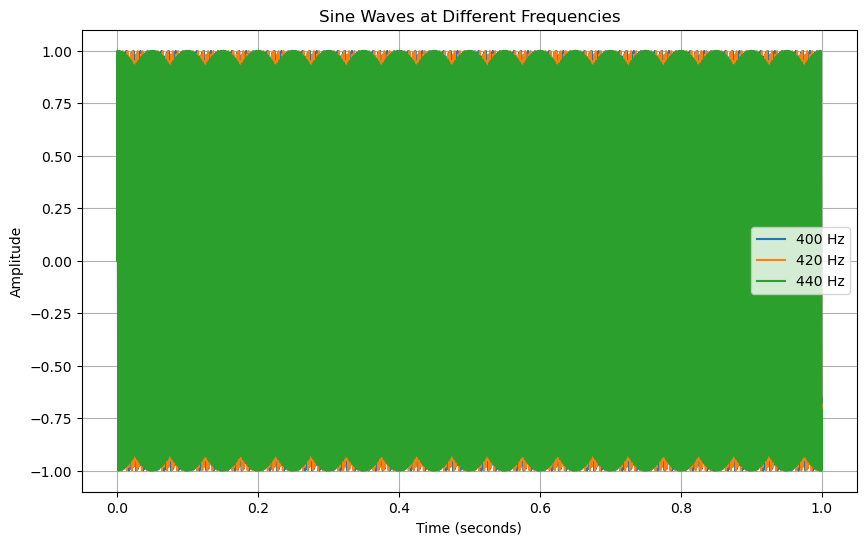

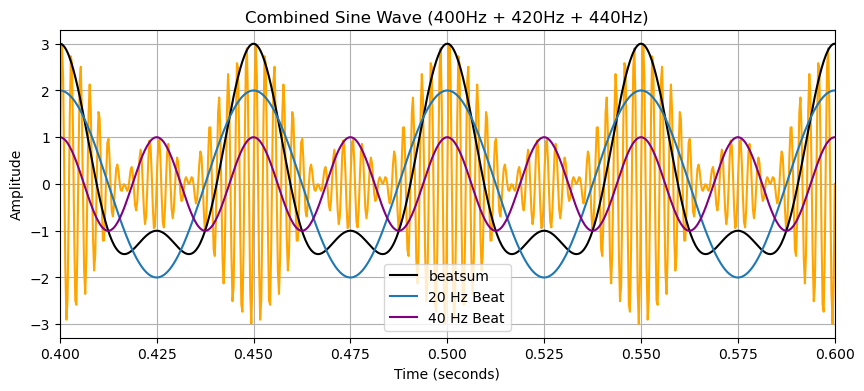

In [66]:
#Can we model a superposition of 3+ wavefunctions with beat frequency(s)? 

#(Caleb Fowler's Code)


import matplotlib.pyplot as plt
import scipy as sci
import numpy as np

# 1. Define time parameters
sampling_rate = 3500  # Samples per second
duration = 1.0        # Total time in seconds
t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)

# 2. Define frequencies (in Hz)
f1 = 400   # 2 cycles per second
f2 = 420   # 5 cycles per second
f3 = 440  # 10 cycles per second

# 3. Generate sine waves
wave_1 = np.sin(2 * np.pi * f1 * t)
wave_2 = np.sin(2 * np.pi * f2 * t)
wave_3 = np.sin(2 * np.pi * f3 * t)

beat12 = np.cos(2 * np.pi * np.abs(f1-f2) * t)
beat13 = np.cos(2 * np.pi * np.abs(f1-f3) * t)
beat23 = np.cos(2 * np.pi * np.abs(f2-f3) * t)


beatsum = beat12 + beat13 + beat23

# 4. Plot the waves
plt.figure(figsize=(10, 6))
plt.plot(t, wave_1, label=f'{f1} Hz')
plt.plot(t, wave_2, label=f'{f2} Hz')
plt.plot(t, wave_3, label=f'{f3} Hz')

plt.title('Sine Waves at Different Frequencies')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

# Summing the waves from the previous example
composite_wave = wave_1 + wave_2 + wave_3

plt.figure(figsize=(10, 4))
plt.plot(t, composite_wave, color='orange')
plt.plot(t, beatsum, label = 'beatsum', color='black')
plt.plot(t, (2*np.cos(2 * np.pi * 20 * t)), label = '20 Hz Beat')
plt.plot(t, (np.cos(2 * np.pi * 40 * t)), color = 'purple', label = '40 Hz Beat')
#plt.plot(t, np.abs(np.sin(2 * np.pi * 30 * t)), color = 'green')
#plt.plot(t, (np.cos(2 * np.pi * 60 * t)), color = 'blue')
plt.title('Combined Sine Wave (400Hz + 420Hz + 440Hz)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.xlim(0.4,0.6)
plt.show()



In [ ]:
    #can we animate superpositioned wavefunction(s) and their beat frequencies?
    
    
    

In [ ]:
#How do audio of beat frequency compare to audio of original superposition of wavefunction? (Can beat frequencies be used to model/recreate the audio somehow?)





When adding different types of wavefunctions we quickly found out that the beat frequencies became very complex, very quickly, making the superposition of various types of wavefunctions (sine, sawtooth, and squarewave). 

(np.float64(-0.01), np.float64(0.2), np.float64(-3.0), np.float64(3.0))

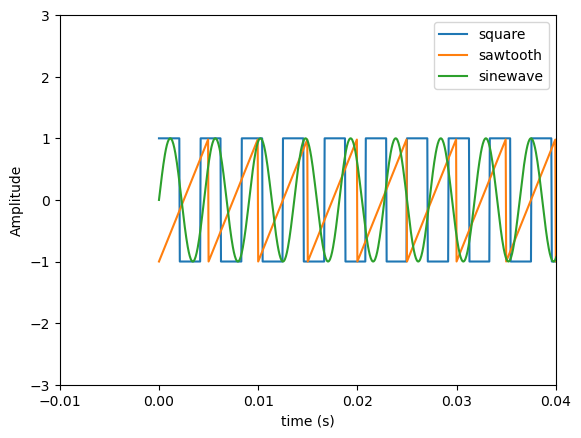

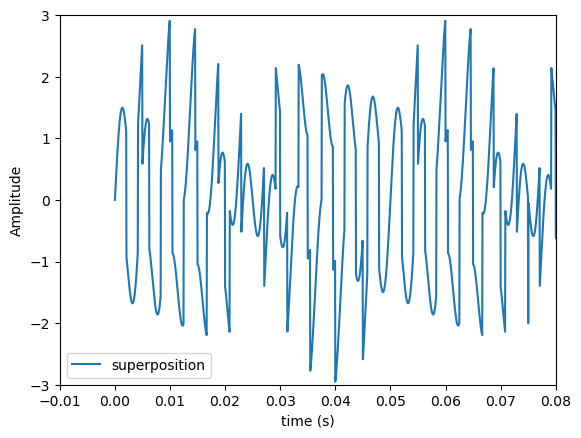

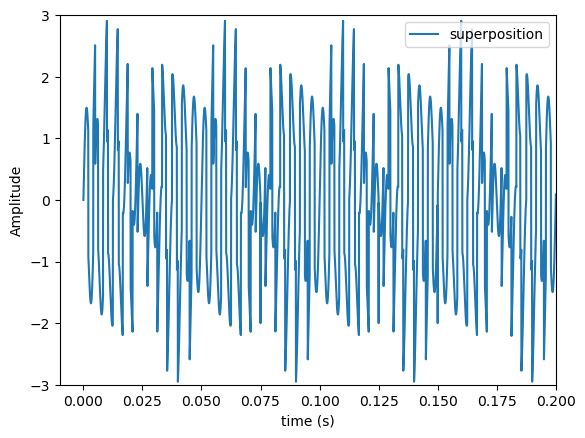

In [65]:
#How does the beat frequency of a superposition of wavefunctions change or affected when different types of waveforms are added? 


#Jack's Code

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

t = np.arange(0, 12*np.pi, 0.00005)

#Function is the superposition of 3 wave functions with different frequencies
sf = 240
tf = 200
wf = 220


square = signal.square(2*sf*np.pi* t)
triangle = signal.sawtooth(2*tf*np.pi*t)
sinwave = np.sin(wf*2*np.pi*t)
superwave = (square+triangle+sinwave)

#Plotting individual wavefunctions
plt.figure(0)
plt.plot(t, square, label = 'square')
plt.plot(t, triangle, label = 'sawtooth')
plt.plot(t, sinwave, label = 'sinewave')
plt.legend()
plt.xlabel('time (s)')
plt.ylabel('Amplitude')
plt.axis((-0.01,0.04,-3,3))


#Plotting superposition
plt.figure(1)
plt.plot(t, superwave, label = 'superposition')
#plt.plot(t, 2*np.cos(1*2*np.pi*t), label = 'beat 1 Hz')
#plt.plot(t, np.cos(2*2*np.pi*t), label = 'beat 2 Hz')
plt.xlabel('time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.axis((-0.01,0.08,-3,3))


plt.figure(2)
plt.plot(t, superwave, label = 'superposition')
#plt.plot(t, 2*np.cos(1*2*np.pi*t), label = 'beat 1 Hz')
#plt.plot(t, np.cos(2*2*np.pi*t), label = 'beat 2 Hz')
plt.xlabel('time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.axis((-0.01,0.2,-3,3))


What we noticed when varying the frequency of triangle and square wave functions was an increasingly complex superposition. The reasoning behind it seemed to be due to the fact that scipy uses a superposition of sin or cos functions to model a square or sawtooth wavefunction, so when you're adding a simple square or triangle wave to your superposition of wavefunctions, you are really adding very very many sin or cos functions to the superposition. 

In short, instead of adding a single frequency, you're adding many frequencies with the addition of a single triangle or square wave. This can be shown via the fourrier transformations of each individual function as well as the super position below. 

Text(0.5, 1.0, 'Superpositioned wave')

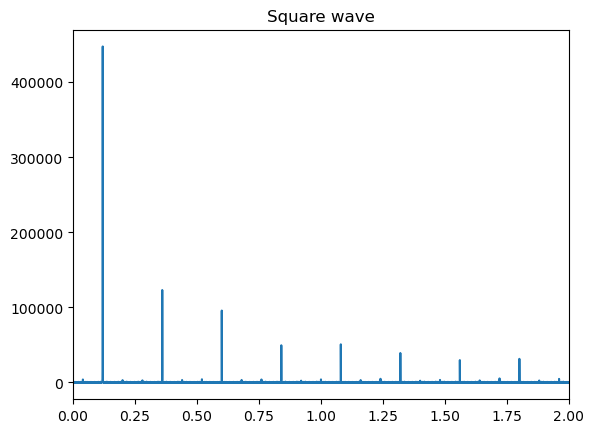

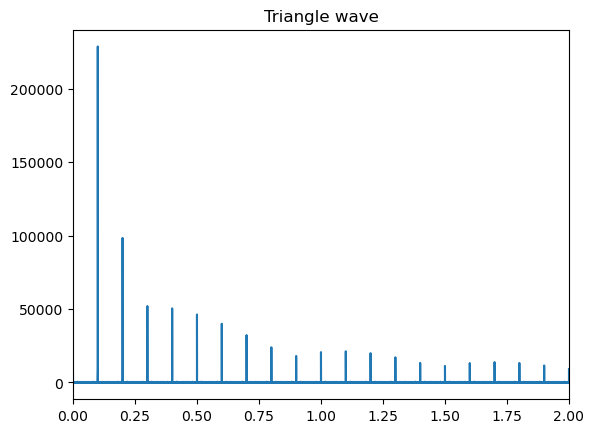

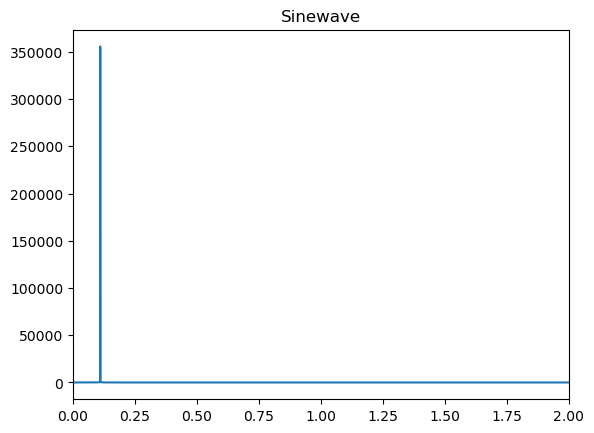

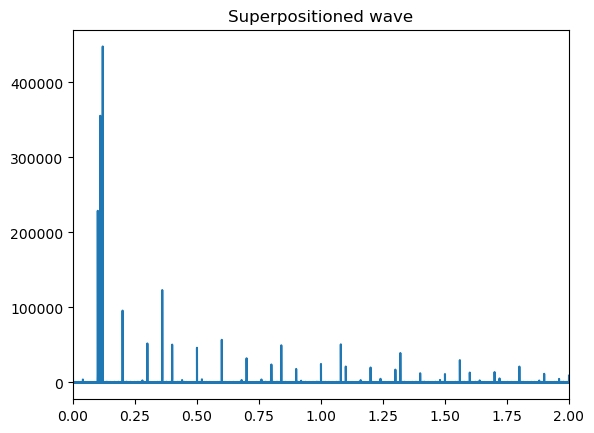

In [62]:
import scipy

dt = 0.1

#fft for square wave
sqn = scipy.fft.rfft(square)
fftFreqSq = scipy.fft.rfftfreq(len(t), dt)


plt.figure(0)
plt.plot(fftFreqSq, np.abs(sqn))
plt.xlim(0,2)
plt.title('Square wave');


#fft for triangle wave
trin = scipy.fft.rfft(triangle)
fftFreqTri = scipy.fft.rfftfreq(len(t), dt)


plt.figure(1)
plt.plot(fftFreqTri, np.abs(trin))
plt.xlim(0,2)
plt.title('Triangle wave')


#fft for sinewave
Sin = scipy.fft.rfft(sinwave)
fftFreqSin = scipy.fft.rfftfreq(len(t), dt)


plt.figure(2)
plt.plot(fftFreqSin, np.abs(Sin))
plt.xlim(0,2)
plt.title('Sinewave')


#fft for Superposition
Supn = scipy.fft.rfft(superwave)
fftFreqSup = scipy.fft.rfftfreq(len(t), dt)


plt.figure(3)
plt.plot(fftFreqSup, np.abs(Supn))
plt.xlim(0,2)
plt.title('Superpositioned wave')


Because every individual frequency present creates a beat frequency with every other beat present you end up with (n-1)! beat frequencies where n is the number of frequencies present in the superposition wave